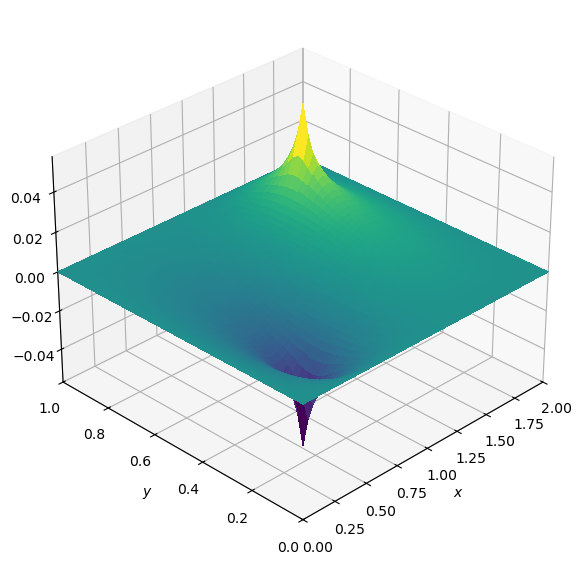

In [8]:
# 2D Poisson Equation 场的分布由边界 + 内部源共同决定

import numpy
from matplotlib import pyplot, cm
from mpl_toolkits.mplot3d import Axes3D


def plot2D(x, y, p):
    fig = pyplot.figure(figsize=(11, 7), dpi=100)
    ax = fig.add_subplot(projection='3d')
    X, Y = numpy.meshgrid(x, y)
    ax.plot_surface(X, Y, p, cmap=cm.viridis, linewidth=0, antialiased=False) # 绘制3D曲面：X/Y网格，p是高度，viridis配色，无线条、关闭抗锯齿
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 1)
    ax.view_init(30, 225) # 设置3D图视角：仰角30°，方位角225°（最佳观察角度）
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')

nx = 50
ny = 50
nt = 10000
xmin = 0
xmax = 2
ymin = 0
ymax = 1

dx = (xmax - xmin) / (nx - 1)
dy = (ymax - ymin) / (ny - 1)

p = numpy.zeros((ny, nx))
pd = numpy.zeros((ny, nx))
b = numpy.zeros((ny, nx))
x = numpy.linspace(xmin, xmax, nx)
y = numpy.linspace(ymin, ymax, ny)    

b[int(ny / 4), int(nx / 4)] = 100                  # [12.5,12.5]  正源
b[int(3 * ny / 4), int(3 * nx / 4)] = -100         # [37.5,37.5]  负源

for it in range(nt):
    pd = p.copy()

    p[1:-1,1:-1] = (((pd[1:-1, 2:] + pd[1:-1, 0:-2]) * dy**2 + 
                    (pd[2:, 1:-1] + pd[0:-2, 1:-1]) * dx**2 -
                    b[1:-1, 1:-1] * dx**2 * dy**2) / 
                    (2 * (dx**2 + dy**2)))
    p[0, :] = 0         # 下 y=0
    p[ny-1, :] = 0      # 上 y=1
    p[:, 0] = 0         # 左 x=0
    p[:, nx-1] =0       # 右 x=2
    
plot2D(x, y, p)